In [9]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

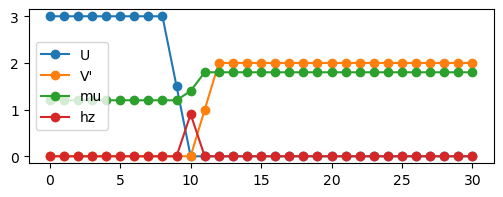

In [10]:
widthS = 10
widthF = 1
widthP = 20

X, Y = widthS+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.01

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthS:widthS + widthF] = h0

V = None

U0 = 3.0 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V_prime0 = 2 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthS] = 0
V_prime[widthF+widthS] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

In [11]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime,
                F0_init=0.1,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[-0.1, 0.1, -0.1j, 0.1j],
                hx=h) #/np.sqrt(2), hy=h/np.sqrt(2))

In [12]:
bdg_sc(H, atol=1e-4, rtol=0.01, maxiter=200, temperature=T)
F, Fuu, Fdd = H.get_correlations()

Converged after 30 iterations


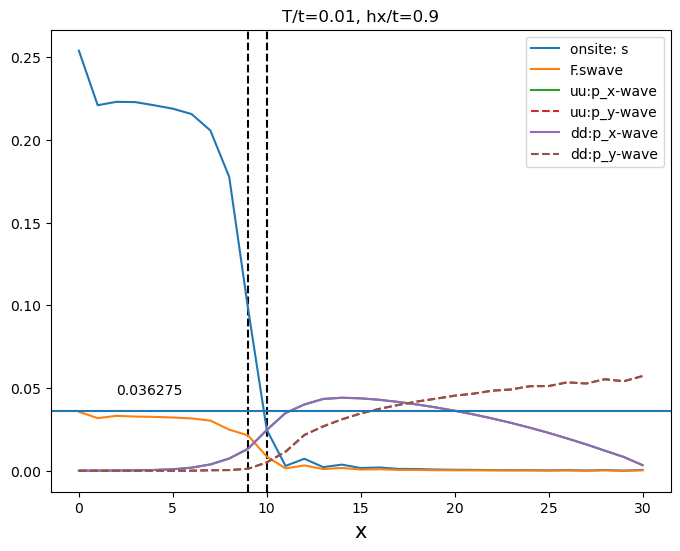

In [13]:
x = np.arange(0, widthS + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={h0}")
axs.axvline(int(widthS)-1, color='black', linestyle='--')
axs.axvline(widthS+widthF-1, color='black', linestyle='--')

# axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
# axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
# axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(H.F0), label="onsite: s")
axs.plot(x, np.abs(F.swave), label="F.swave")

axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.plot(x, np.abs(Fdd.px), label="dd:p_x-wave")
axs.plot(x, np.abs(Fdd.py), "--", label="dd:p_y-wave")

# axs.plot(x, (np.abs(Fuu.px) + np.abs(Fdd.px))/2, label="uu-dd:p_x-wave")
# axs.plot(x, (np.abs(Fuu.py) + np.abs(Fdd.py))/2, "--", label="uu+dd:p_y-wave")

axs.set_xlabel("x", fontsize=15)
axs.axhline(np.abs(Fuu.px)[20])
axs.text(2, (np.abs(Fuu.px))[20]+0.01, f"{(np.abs(Fuu.px))[20]:.6f}")
axs.legend()
plt.show()

In [17]:
print(Fuu.px[20])
print(Fuu.py[20])


(0.03627488922339273-6.766564629684438e-07j)
(1.210631958064704e-06+0.04538139995371819j)


In [15]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.30 + 1e-12, 0.01),
    np.arange(0.31, 0.60 + 1e-12, 0.002)
])
print(len(temps))

185


In [16]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.30 + 1e-12, 0.01),
    np.arange(0.31, 0.41 + 1e-12, 0.001),
    np.arange(0.42, 0.60 + 1e-12, 0.002)
])  # 231 temps total
print(len(temps))

231
